# Ejercicios Teléfonos
## Emilio León
### Miércoles 11/02/2026

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import numpy as np
from numpy.ma.extras import median

In [4]:
df_tels = pd.read_csv("datos_telecomunicaciones-2-1.csv", index_col= "cliente_id", header=0)
df_tels

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,NaN,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,NaN
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


In [5]:
df_tels.isna().sum()

edad            1
genero          0
plan            0
llamadas_mes    1
minutos_mes     0
recarga_mes     1
dtype: int64

### Las columnas edad, llamadas_mes y recarga mes tienen valores faltantes, uno cada una.

In [6]:
df_tels.loc[df_tels[["edad", "llamadas_mes", "recarga_mes"]].isna().any(axis=1)]

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,NaN,120,50.0
6,28.0,Femenino,A,40.0,100,NaN
13,NaN,Masculino,C,70.0,250,120.0


### El registro 1, 6, y 13 tienen valores faltantes.

In [7]:
df_mod=df_tels.dropna(how="all", subset=["edad"])
pd.DataFrame(df_mod)
df_mod

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,NaN,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,NaN
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


### Se eliminó una sóla columna del dataframe

In [8]:
llam_mes= df_mod["llamadas_mes"].fillna(df_mod["llamadas_mes"].median())
pd.DataFrame(llam_mes)
llam_mes

cliente_id
1     60.0
2     60.0
3     50.0
4     70.0
5     80.0
6     40.0
7     90.0
8     50.0
9     60.0
10    70.0
11    50.0
12    60.0
14    40.0
15    80.0
16    50.0
17    60.0
18    70.0
Name: llamadas_mes, dtype: float64

In [9]:
rec_mes = df_mod["recarga_mes"].ffill()
pd.DataFrame(rec_mes)
rec_mes

cliente_id
1      50.0
2     100.0
3      75.0
4     120.0
5     150.0
6     150.0
7     180.0
8      90.0
9     110.0
10    140.0
11     75.0
12    100.0
14     50.0
15    150.0
16     90.0
17    110.0
18    140.0
Name: recarga_mes, dtype: float64

In [10]:
df_mod.loc[:,"llamadas_mes"] = llam_mes
df_mod

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,60.0,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,NaN
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


In [11]:
df_mod.loc[:,"recarga_mes"] = rec_mes
df_mod

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,60.0,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,150.0
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


In [12]:
df_dup = df_mod.duplicated()
df_dup

cliente_id
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
14    False
15     True
16    False
17    False
18    False
dtype: bool

### Solo hay una fila duplicada, la 15.

In [13]:
df_final = df_mod.drop_duplicates()
df_final

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,60.0,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,150.0
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


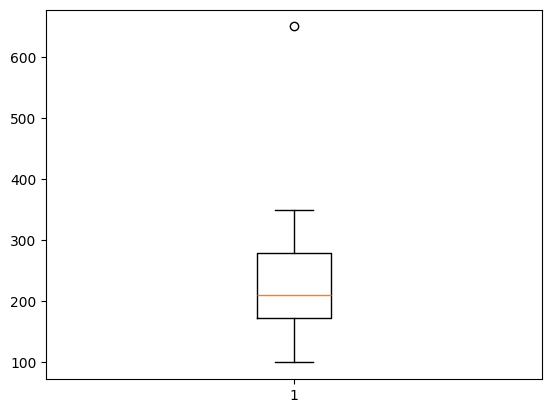

In [14]:
plt.boxplot(df_final["minutos_mes"])
plt.show()

In [15]:
q1 = df_final["minutos_mes"].quantile(0.25)
q3 = df_final["minutos_mes"].quantile(0.75)
IQR = q3 - q1
print(IQR)

107.5


### ElIQR = 107.5

In [16]:
lim_inf = round(q1-1.5*IQR)
lim_sup = round(q3+1.5*IQR)
print(lim_inf, lim_sup)

11 441


In [17]:
outliers = df_final[(df_final["minutos_mes"] > lim_sup) | (df_final["minutos_mes"] < lim_inf)]
outliers

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
11,25.0,Masculino,A,50.0,650,75.0


In [18]:
df_final.loc[df_final["minutos_mes"] > lim_sup, "minutos_mes"] = lim_sup
df_final

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,60.0,120,50.0
2,35.0,Femenino,B,60.0,200,100.0
3,22.0,Masculino,A,50.0,150,75.0
4,25.0,Femenino,C,70.0,250,120.0
5,35.0,Masculino,B,80.0,300,150.0
6,28.0,Femenino,A,40.0,100,150.0
7,40.0,Masculino,C,90.0,350,180.0
8,22.0,Femenino,B,50.0,180,90.0
9,35.0,Masculino,A,60.0,220,110.0


In [28]:
scaler = MinMaxScaler()
df_final.loc[:,"minutos_mes"] = scaler.fit_transform(df_final[["minutos_mes"]])
df_final

,edad,genero,plan,llamadas_mes,minutos_mes,recarga_mes
cliente_id,,,,,,
1,25.0,Masculino,A,60.0,0.058651,50.0
2,35.0,Femenino,B,60.0,0.293255,100.0
3,22.0,Masculino,A,50.0,0.146628,75.0
4,25.0,Femenino,C,70.0,0.439883,120.0
5,35.0,Masculino,B,80.0,0.586510,150.0
6,28.0,Femenino,A,40.0,0.000000,150.0
7,40.0,Masculino,C,90.0,0.733138,180.0
8,22.0,Femenino,B,50.0,0.234604,90.0
9,35.0,Masculino,A,60.0,0.351906,110.0
